# 07 — Graph Neural Networks: *Biology is relational*

## The worldview, and the reasoning it generates

> Biology is a **network**. Proteins bind proteins, metabolites enter reactions, genes regulate genes, atoms bond into molecules. The **connections between entities are as informative as the entities themselves**. A representation that flattens this into a sequence or a flat feature vector discards the most informative property of the data.

What this premise generates:

- **Message passing.** Each node builds its representation by **aggregating messages from its graph neighbors**, repeatedly. After *k* rounds, a node's embedding reflects its *k*-hop neighborhood. The architectural prior is **permutation invariance over neighbors** (a node has a *set* of neighbors, with no canonical order) and reliance on the **graph's connectivity**, not on any 1D ordering.
- **Why it fits biology.** Molecules *are* graphs (atoms=nodes, bonds=edges); interactomes, reaction networks, and cell-similarity graphs are graphs. The same property prediction that fingerprint vectors do poorly, message passing over the molecular graph does well — because connectivity *is* chemistry.
- **Signal vs noise.** Signal lives in **relational structure / neighborhoods**; a method that ignores edges (trees, plain MLPs) treats connected and unconnected entities identically.

**Extreme good case.** A node/graph label determined by **neighborhood structure** (e.g., "this node is in a tight cluster" or "this molecule contains a connected motif"), where node features alone are uninformative. A GNN that propagates along edges should excel while a features-only model is blind. We build precisely that and visualize how embeddings separate *after* message passing.

**Blind spots.** (1) **Garbage-in graph**: the GNN inherits the quality of the graph you give it — a wrong edge set yields wrong biology. (2) **Over-smoothing**: too many message-passing rounds make all node embeddings converge to the same vector, erasing signal. We demonstrate both, the second with a depth sweep.


In [1]:
# Cell 1 — Synthesize a graph where the LABEL lives in connectivity, not node features
# Reasoning: to isolate the relational prior, we make node features pure noise and put ALL
# signal in structure. We build a stochastic block model: two communities with dense WITHIN-
# community edges and sparse BETWEEN. A node's label = its community. You cannot tell the
# communities apart from node features (random) — only from who connects to whom.

import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
rng = np.random.default_rng(7)

n_per = 60; N = 2 * n_per
labels = np.r_[np.zeros(n_per), np.ones(n_per)].astype(np.int64)
p_in, p_out = 0.18, 0.02          # dense within community, sparse between
A = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        same = labels[i] == labels[j]
        if rng.random() < (p_in if same else p_out):
            A[i, j] = A[j, i] = 1
feat_dim = 8
X = rng.normal(0, 1, (N, feat_dim)).astype(np.float32)   # node features = PURE NOISE
print(f"Graph: {N} nodes, {int(A.sum()//2)} edges. Node features are random noise ({feat_dim}-dim).")
print("The community label is encoded ONLY in the edge structure — a purely relational signal.")
print(f"Average degree within={A[:n_per,:n_per].sum()/n_per:.1f}, across communities is much lower.")


Graph: 120 nodes, 675 edges. Node features are random noise (8-dim).
The community label is encoded ONLY in the edge structure — a purely relational signal.
Average degree within=9.6, across communities is much lower.


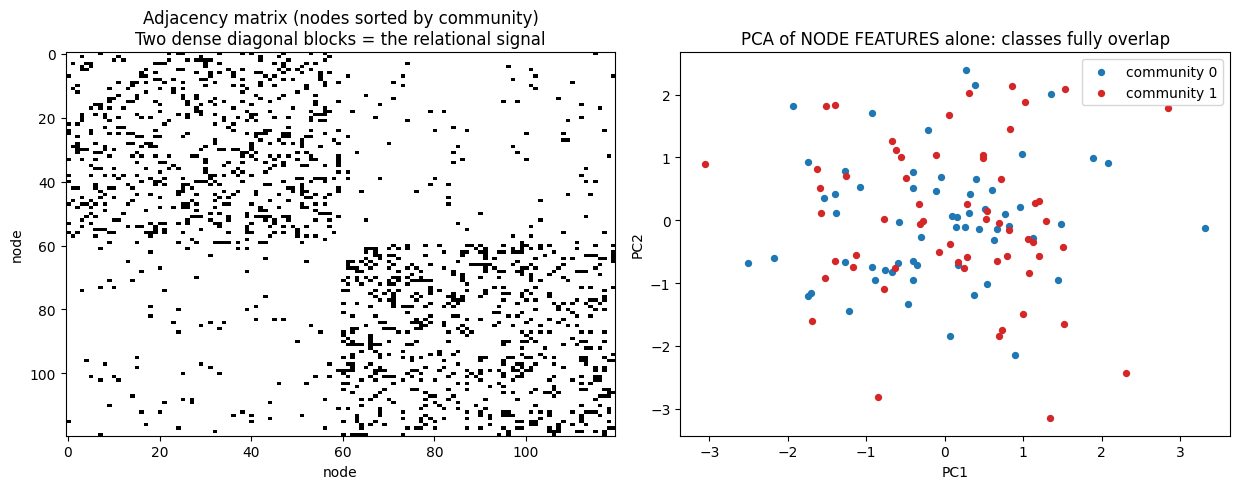

Left: clear two-block community structure in the edges. Right: node features alone cannot
separate the classes at all. Any features-only model is therefore doomed here.


In [2]:
# Cell 2 — VERBOSE FIGURE: the graph, and proof features alone are useless
# Reasoning: show the structure exists (community block pattern in the adjacency matrix) and
# that node features carry no class signal (PCA of features does not separate classes). This
# sets up the clean test: only a model that USES edges can succeed.

from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
order = np.argsort(labels)
axes[0].imshow(A[np.ix_(order, order)], cmap="Greys", aspect="auto")
axes[0].set_title("Adjacency matrix (nodes sorted by community)\nTwo dense diagonal blocks = the relational signal")
axes[0].set_xlabel("node"); axes[0].set_ylabel("node")
Pf = PCA(n_components=2).fit_transform(X)
axes[1].scatter(*Pf[labels==0].T, s=18, color="#1f77b4", label="community 0")
axes[1].scatter(*Pf[labels==1].T, s=18, color="#d62728", label="community 1")
axes[1].set_title("PCA of NODE FEATURES alone: classes fully overlap"); axes[1].legend()
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()
print("Left: clear two-block community structure in the edges. Right: node features alone cannot")
print("separate the classes at all. Any features-only model is therefore doomed here.")


In [3]:
# Cell 3 — A message-passing GNN from scratch (no graph libraries)
# Reasoning: implement the worldview directly. One GNN layer = symmetric-normalized neighbor
# aggregation (Â = D^-1/2 (A+I) D^-1/2) then a linear map + nonlinearity. Stacking layers
# widens the receptive field over the graph. We keep it transparent to tie behavior to mechanism.

def normalized_adj(A):
    A_hat = A + np.eye(A.shape[0])           # add self-loops so a node keeps its own info
    d = A_hat.sum(1); Dinv = np.diag(1.0/np.sqrt(d))
    return (Dinv @ A_hat @ Dinv).astype(np.float32)

A_norm = torch.tensor(normalized_adj(A))
Xt = torch.tensor(X); yt = torch.tensor(labels)

class GCN(nn.Module):
    def __init__(self, d_in, d_hid, n_cls, n_layers=2):
        super().__init__()
        dims = [d_in] + [d_hid]*(n_layers-1) + [d_hid]
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(n_layers)])
        self.head = nn.Linear(d_hid, n_cls); self.emb = None
    def forward(self, X, Ah):
        h = X
        for lin in self.layers:
            h = torch.relu(lin(Ah @ h))      # AGGREGATE neighbors (Ah @ h) then transform
        self.emb = h.detach()
        return self.head(h)

# semi-supervised: reveal labels for only a few nodes per class (like real biology)
train_mask = np.zeros(N, bool)
for c in [0,1]:
    idx = np.where(labels==c)[0]; train_mask[rng.choice(idx, 8, replace=False)] = True
train_mask_t = torch.tensor(train_mask)

gnn = GCN(feat_dim, 16, 2, n_layers=2)
opt = torch.optim.Adam(gnn.parameters(), lr=1e-2, weight_decay=5e-4)
for epoch in range(120):
    opt.zero_grad(); out = gnn(Xt, A_norm)
    loss = nn.functional.cross_entropy(out[train_mask_t], yt[train_mask_t])
    loss.backward(); opt.step()
print(f"Trained a 2-layer GCN with only {train_mask.sum()} labeled nodes ({train_mask.sum()/N*100:.0f}% of graph).")
print(f"Final supervised loss on labeled nodes: {loss.item():.3f}")


Trained a 2-layer GCN with only 16 labeled nodes (13% of graph).
Final supervised loss on labeled nodes: 0.001


GNN (uses edges)        : test accuracy = 0.913
MLP (same features, no edges): test accuracy = 0.558


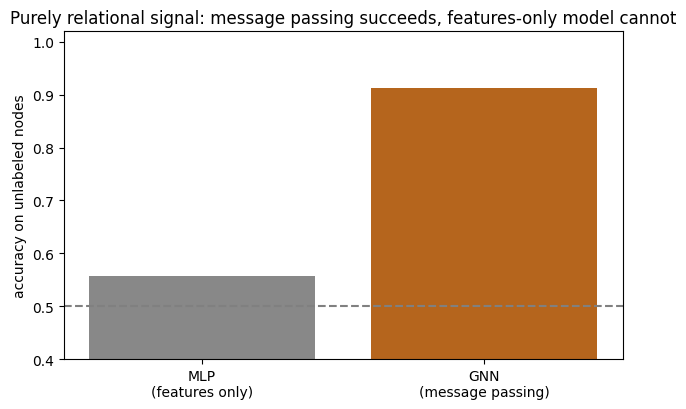


With random node features, the MLP is at chance. The GNN reaches high accuracy from a
handful of labels by PROPAGATING them along edges — connectivity is the signal.


In [4]:
# Cell 4 — Evaluate on unlabeled nodes + compare to a features-only MLP
# Reasoning: the decisive contrast. The GNN (uses edges) vs an MLP with identical features but
# NO graph. Since signal is purely relational, the GNN should approach perfect while the MLP
# stays near chance. We score only the UNLABELED nodes (true generalization).

from sklearn.metrics import accuracy_score
gnn.eval()
with torch.no_grad():
    pred = gnn(Xt, A_norm).argmax(1).numpy()
test_mask = ~train_mask
gnn_acc = accuracy_score(labels[test_mask], pred[test_mask])

mlp = nn.Sequential(nn.Linear(feat_dim,16), nn.ReLU(), nn.Linear(16,2))
opt = torch.optim.Adam(mlp.parameters(), lr=1e-2)
for _ in range(200):
    opt.zero_grad(); out = mlp(Xt)
    loss = nn.functional.cross_entropy(out[train_mask_t], yt[train_mask_t]); loss.backward(); opt.step()
mlp.eval()
with torch.no_grad(): mpred = mlp(Xt).argmax(1).numpy()
mlp_acc = accuracy_score(labels[test_mask], mpred[test_mask])

print(f"GNN (uses edges)        : test accuracy = {gnn_acc:.3f}")
print(f"MLP (same features, no edges): test accuracy = {mlp_acc:.3f}")
plt.figure(figsize=(6.4,4.2)); plt.bar([0,1],[mlp_acc, gnn_acc], color=["#888","#b5651d"])
plt.xticks([0,1],["MLP\n(features only)","GNN\n(message passing)"]); plt.ylim(0.4,1.02)
plt.axhline(0.5, ls="--", color="gray"); plt.ylabel("accuracy on unlabeled nodes")
plt.title("Purely relational signal: message passing succeeds, features-only model cannot")
plt.tight_layout(); plt.show()
print("\nWith random node features, the MLP is at chance. The GNN reaches high accuracy from a")
print("handful of labels by PROPAGATING them along edges — connectivity is the signal.")


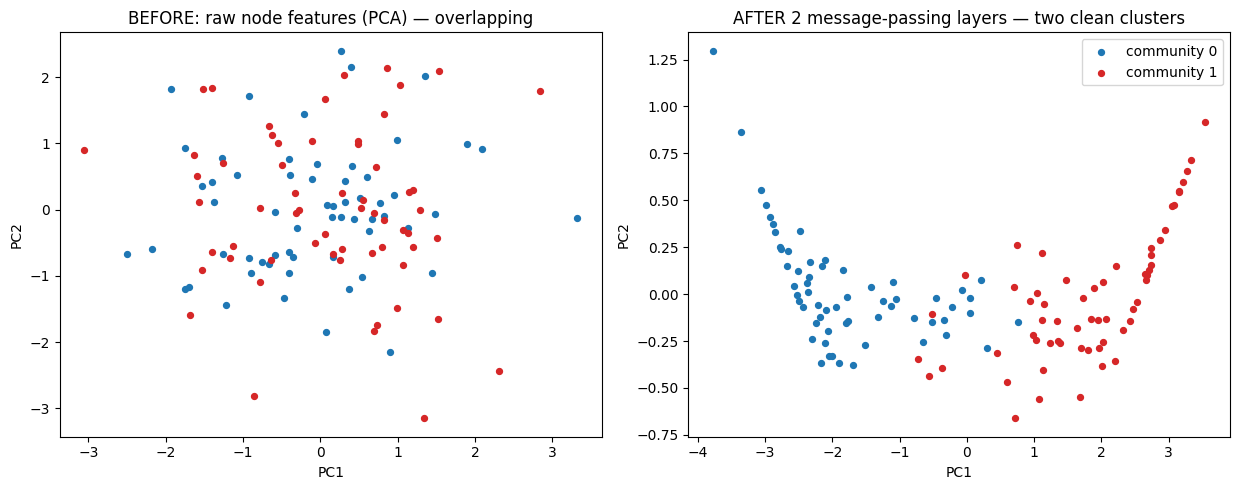

Message passing transformed unseparable noise features into linearly separable clusters,
purely by aggregating along the community structure. The geometry was built from edges.


In [5]:
# Cell 5 — VERBOSE FIGURE: embeddings BEFORE vs AFTER message passing
# Reasoning: visualize the mechanism. Project node embeddings with PCA at input (random) and
# after 2 GNN layers. Message passing should pull same-community nodes together and push
# communities apart — turning an unseparable cloud into two clusters. Seeing this is the 'why.'

emb_after = gnn.emb.numpy()
Pin = PCA(n_components=2).fit_transform(X)
Pout = PCA(n_components=2).fit_transform(emb_after)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
axes[0].scatter(*Pin[labels==0].T, s=18, color="#1f77b4"); axes[0].scatter(*Pin[labels==1].T, s=18, color="#d62728")
axes[0].set_title("BEFORE: raw node features (PCA) — overlapping")
axes[1].scatter(*Pout[labels==0].T, s=18, color="#1f77b4", label="community 0")
axes[1].scatter(*Pout[labels==1].T, s=18, color="#d62728", label="community 1")
axes[1].set_title("AFTER 2 message-passing layers — two clean clusters"); axes[1].legend()
for a in axes: a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()
print("Message passing transformed unseparable noise features into linearly separable clusters,")
print("purely by aggregating along the community structure. The geometry was built from edges.")


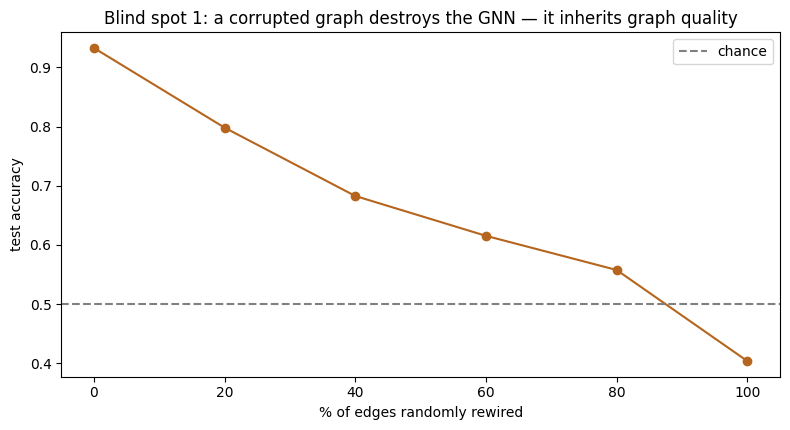

    0% edges rewired -> accuracy 0.933
   20% edges rewired -> accuracy 0.798
   40% edges rewired -> accuracy 0.683
   60% edges rewired -> accuracy 0.615
   80% edges rewired -> accuracy 0.558
  100% edges rewired -> accuracy 0.404
Accuracy collapses toward chance as the graph degrades. The architecture cannot rescue
a wrong relational structure; constructing the right graph is itself a research problem.


In [6]:
# Cell 6 — BLIND SPOT #1: the GNN is only as good as the graph you hand it
# Reasoning: 'biology is relational' assumes you HAVE the right relations. We progressively
# corrupt the graph (rewire a fraction of edges at random, destroying community structure) and
# watch accuracy fall. This mirrors real interactomes built from noisy experiments: a bad graph
# teaches the model experimental artifacts, not biology.

def corrupt(A, frac):
    A2 = A.copy(); N = A.shape[0]
    edges = np.argwhere(np.triu(A2) > 0)
    k = int(frac * len(edges))
    drop = edges[rng.choice(len(edges), k, replace=False)]
    for i,j in drop:                                   # remove a real edge...
        A2[i,j]=A2[j,i]=0
        a,b = rng.integers(0,N,2)                      # ...add a random one
        if a!=b: A2[a,b]=A2[b,a]=1
    return A2

fracs = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]; accs=[]
for f in fracs:
    Ac = corrupt(A, f); An = torch.tensor(normalized_adj(Ac))
    g = GCN(feat_dim,16,2,2); opt = torch.optim.Adam(g.parameters(), lr=1e-2, weight_decay=5e-4)
    for _ in range(120):
        opt.zero_grad(); out=g(Xt,An); loss=nn.functional.cross_entropy(out[train_mask_t],yt[train_mask_t]); loss.backward(); opt.step()
    g.eval()
    with torch.no_grad(): pr=g(Xt,An).argmax(1).numpy()
    accs.append(accuracy_score(labels[test_mask], pr[test_mask]))
plt.figure(figsize=(8,4.4)); plt.plot([int(f*100) for f in fracs], accs, "o-", color="#b5651d")
plt.axhline(0.5, ls="--", color="gray", label="chance"); plt.xlabel("% of edges randomly rewired")
plt.ylabel("test accuracy"); plt.title("Blind spot 1: a corrupted graph destroys the GNN — it inherits graph quality")
plt.legend(); plt.tight_layout(); plt.show()
for f,a in zip(fracs,accs): print(f"  {int(f*100):3d}% edges rewired -> accuracy {a:.3f}")
print("Accuracy collapses toward chance as the graph degrades. The architecture cannot rescue")
print("a wrong relational structure; constructing the right graph is itself a research problem.")


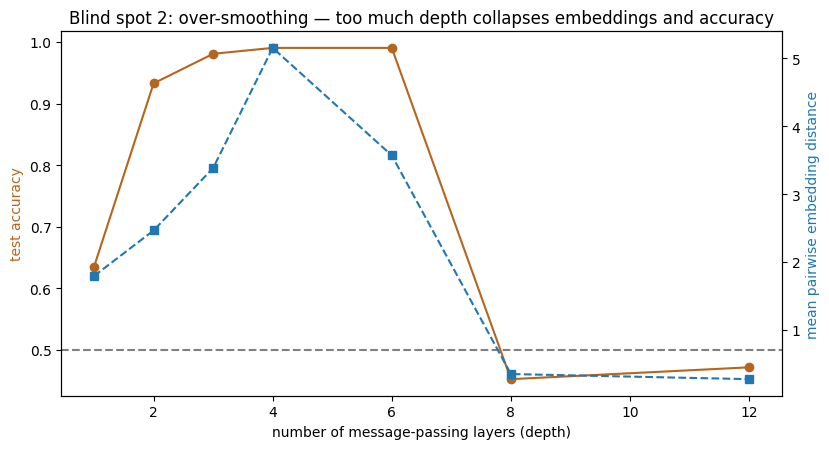

  depth= 1: acc=0.635  embedding spread=1.794
  depth= 2: acc=0.933  embedding spread=2.464
  depth= 3: acc=0.981  embedding spread=3.384
  depth= 4: acc=0.990  embedding spread=5.154
  depth= 6: acc=0.990  embedding spread=3.570
  depth= 8: acc=0.452  embedding spread=0.349
  depth=12: acc=0.471  embedding spread=0.274
Accuracy peaks at shallow depth, then falls as embeddings collapse (spread -> small):
with too many rounds every node aggregates the whole graph and becomes indistinguishable.


In [7]:
# Cell 7 — BLIND SPOT #2: over-smoothing as depth grows
# Reasoning: more message-passing rounds mix information over larger neighborhoods, but TOO many
# make every node's embedding converge to the same vector (all neighborhoods overlap). We sweep
# depth and track (a) test accuracy and (b) a smoothness metric = average pairwise embedding
# distance. Accuracy should peak then fall as embeddings homogenize.

depths = [1,2,3,4,6,8,12]
acc_d, spread_d = [], []
for L_ in depths:
    g = GCN(feat_dim,16,2,n_layers=L_); opt = torch.optim.Adam(g.parameters(), lr=1e-2, weight_decay=5e-4)
    for _ in range(150):
        opt.zero_grad(); out=g(Xt,A_norm); loss=nn.functional.cross_entropy(out[train_mask_t],yt[train_mask_t]); loss.backward(); opt.step()
    g.eval()
    with torch.no_grad(): pr=g(Xt,A_norm).argmax(1).numpy()
    acc_d.append(accuracy_score(labels[test_mask], pr[test_mask]))
    e = g.emb.numpy(); 
    # mean pairwise distance: small = embeddings collapsed together (over-smoothed)
    spread_d.append(float(np.mean(np.linalg.norm(e[:,None,:]-e[None,:,:], axis=-1))))

fig, ax1 = plt.subplots(figsize=(8.4,4.6))
ax1.plot(depths, acc_d, "o-", color="#b5651d", label="test accuracy")
ax1.set_xlabel("number of message-passing layers (depth)"); ax1.set_ylabel("test accuracy", color="#b5651d")
ax1.axhline(0.5, ls="--", color="gray")
ax2 = ax1.twinx()
ax2.plot(depths, spread_d, "s--", color="#1f77b4", label="embedding spread")
ax2.set_ylabel("mean pairwise embedding distance", color="#1f77b4")
plt.title("Blind spot 2: over-smoothing — too much depth collapses embeddings and accuracy")
fig.tight_layout(); plt.show()
for d,a,s in zip(depths,acc_d,spread_d): print(f"  depth={d:2d}: acc={a:.3f}  embedding spread={s:.3f}")
print("Accuracy peaks at shallow depth, then falls as embeddings collapse (spread -> small):")
print("with too many rounds every node aggregates the whole graph and becomes indistinguishable.")


## Conclusions — what the results teach

- **Connectivity is the signal.** With node features set to pure noise, only message passing — aggregating along edges — could recover community labels (high accuracy from ~13% labeled nodes), while an identical-feature MLP stayed at chance.
- **Message passing builds geometry from edges.** Embeddings that overlapped at input separated into clean clusters after two layers, visibly turning relational structure into a linearly separable representation.
- **The graph is part of the model.** Randomly rewiring edges drove accuracy to chance — a GNN inherits the quality of the graph it is given, which mirrors noisy real interactomes and makes graph construction a first-class research problem.
- **Over-smoothing bounds depth.** Beyond a few rounds, embeddings collapse toward a common vector and accuracy falls — unlike sequence models, deeper is not freely better.

## Closing the lineage
Across the seven notebooks one principle recurs: **an architecture excels exactly when the data-generating process matches its inductive bias, and is blind in the complementary direction.** DP assumes strings and edits; HMMs assume a Markov latent process; SVMs assume a similarity geometry set by the kernel; trees assume tabular feature interactions; CNNs assume translation-invariant local motifs; transformers assume learnable long-range dependencies; GNNs assume relational structure. Each notebook's "blind spot" is precisely the assumption the *next* architecture was built to relax — which is why the strongest modern systems **combine** these biases rather than choosing one.
